In [1]:
import pandas as pd

df = pd.read_csv('/content/improved_multimedia_dataset.csv')
display(df.head())
display(df.info())

,text,topic,source_type,source_credibility,article_length,contradiction_score,semantic_similarity,readability_score,sentiment,trust_score
0,Democracy gives people the right to vote and e...,Politics,Government Website,8,3858,0.66,0.75,78.72,Neutral,74.54
1,Teachers play an important role in student dev...,Education,Research Paper,9,2895,0.87,0.56,89.87,Positive,83.81
2,Financial planning helps individuals manage in...,Finance,Government Website,8,166,0.34,0.50,83.86,Positive,85.50
3,Financial planning helps individuals manage in...,Finance,Government Website,8,4729,0.57,0.48,88.89,Positive,79.80
4,Medical technology helps diagnose diseases mor...,Healthcare,News Article,6,2856,0.88,0.73,59.13,Neutral,54.79


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   text                 1500 non-null   object 
 1   topic                1500 non-null   object 
 2   source_type          1500 non-null   object 
 3   source_credibility   1500 non-null   int64  
 4   article_length       1500 non-null   int64  
 5   contradiction_score  1500 non-null   float64
 6   semantic_similarity  1500 non-null   float64
 7   readability_score    1500 non-null   float64
 8   sentiment            1500 non-null   object 
 9   trust_score          1500 non-null   float64
dtypes: float64(4), int64(2), object(4)
memory usage: 117.3+ KB


None

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define the target variable: 'is_trusted' (1 if trust_score >= 50, 0 otherwise)
df['is_trusted'] = (df['trust_score'] >= 50).astype(int)

# Define features (X) and target (y)
X = df.drop(['trust_score', 'is_trusted', 'text'], axis=1)
y = df['is_trusted']

# Identify numerical and categorical features
numerical_features = ['source_credibility', 'article_length', 'contradiction_score', 'semantic_similarity', 'readability_score']
categorical_features = ['topic', 'source_type', 'sentiment']

# Create a preprocessor using ColumnTransformer for one-hot encoding and scaling
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Data preprocessing complete. Training and testing sets created.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Data preprocessing complete. Training and testing sets created.
X_train shape: (1050, 8), y_train shape: (1050,)
X_test shape: (450, 8), y_test shape: (450,)


2) K-Nearest Neighbors (KNN)


In [5]:
from sklearn.neighbors import NearestNeighbors

# Reuse the preprocessor to transform the entire dataset for KNN
X_processed = preprocessor.fit_transform(X)

# Train the NearestNeighbors model
# We'll use 5 neighbors and 'cosine' similarity for text-based content
knn_model = NearestNeighbors(n_neighbors=5, metric='cosine')
knn_model.fit(X_processed)

print("KNN model trained successfully using preprocessed data.")

KNN model trained successfully using preprocessed data.


In [6]:
# Demonstrate KNN by finding similar content for a sample

# Let's pick a random article from the original dataframe
sample_index = 120 # Example index
sample_content_text = df.loc[sample_index, 'text']
sample_content_topic = df.loc[sample_index, 'topic']

print(f"Finding similar content for: (Index {sample_index})\nTopic: {sample_content_topic}\nText: {sample_content_text[:200]}...\n")

# Preprocess the sample content
sample_data_for_knn = X.iloc[[sample_index]]
sample_processed = preprocessor.transform(sample_data_for_knn)

# Find the 5 nearest neighbors (excluding itself if it's in the dataset)
distances, indices = knn_model.kneighbors(sample_processed)

print("Similar content found:")
for i, idx in enumerate(indices[0]):
    if idx == sample_index: # Skip the sample itself if it's in the results
        continue
    print(f"\n--- Neighbor {i+1} ---")
    print(f"Original Index: {idx}")
    print(f"Topic: {df.loc[idx, 'topic']}")
    print(f"Text: {df.loc[idx, 'text'][:200]}...")
    print(f"Distance: {distances[0][i]:.4f}")

Finding similar content for: (Index 120)
Topic: Technology
Text: Machine learning helps computers learn from data....

Similar content found:

--- Neighbor 2 ---
Original Index: 810
Topic: Technology
Text: Cloud computing allows data storage over the internet....
Distance: 0.1017

--- Neighbor 3 ---
Original Index: 1241
Topic: Technology
Text: Cybersecurity protects systems from digital attacks....
Distance: 0.1492

--- Neighbor 4 ---
Original Index: 836
Topic: Politics
Text: Government policies influence public welfare and economic stability....
Distance: 0.1497

--- Neighbor 5 ---
Original Index: 178
Topic: Technology
Text: Cybersecurity protects systems from digital attacks....
Distance: 0.1833


3)NAIVE BAYES

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

# Define features (text column) and target (topic column)
X_text = df['text']
y_topic = df['topic']

# Split data into training and testing sets for text classification
X_text_train, X_text_test, y_topic_train, y_topic_test = train_test_split(X_text, y_topic, test_size=0.3, random_state=42)

# Create a pipeline with TF-IDF Vectorizer and Multinomial Naive Bayes
text_classifier_model = make_pipeline(TfidfVectorizer(), MultinomialNB())

# Train the model
text_classifier_model.fit(X_text_train, y_topic_train)

print("Naive Bayes text classification model trained successfully.")

Naive Bayes text classification model trained successfully.


In [8]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_topic_pred = text_classifier_model.predict(X_text_test)

# Evaluate the model
accuracy_nb = accuracy_score(y_topic_test, y_topic_pred)

print(f"\nNaive Bayes Model Evaluation (Topic Classification):")
print(f"Accuracy: {accuracy_nb:.4f}")



Naive Bayes Model Evaluation (Topic Classification):
Accuracy: 1.0000


In [9]:
# Example of how the model classifies new content
new_content = [
    "Latest market trends and investment strategies for the new quarter.",
    "Recent breakthroughs in gene editing and their implications for human health.",
    "The role of blockchain in securing digital transactions and data privacy."
]

predicted_topics = text_classifier_model.predict(new_content)

print("\nClassifying new content:")
for i, content in enumerate(new_content):
    print(f"\nContent: {content[:70]}...")
    print(f"Predicted Topic: {predicted_topics[i]}")


Classifying new content:

Content: Latest market trends and investment strategies for the new quarter....
Predicted Topic: Finance

Content: Recent breakthroughs in gene editing and their implications for human ...
Predicted Topic: Politics

Content: The role of blockchain in securing digital transactions and data priva...
Predicted Topic: Finance


4) DECISION TREE

In [10]:
from sklearn.tree import DecisionTreeClassifier

# Reuse the preprocessed data (X_train, y_train, X_test, y_test) and preprocessor from Logistic Regression

# Create a pipeline with the preprocessor and Decision Tree Classifier
decision_tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Train the Decision Tree model
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test)

# Evaluate the Decision Tree model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)

print(f"\nDecision Tree Model Evaluation:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")



Decision Tree Model Evaluation:
Accuracy: 0.9178
Precision: 0.9417
Recall: 0.9446
F1-Score: 0.9432


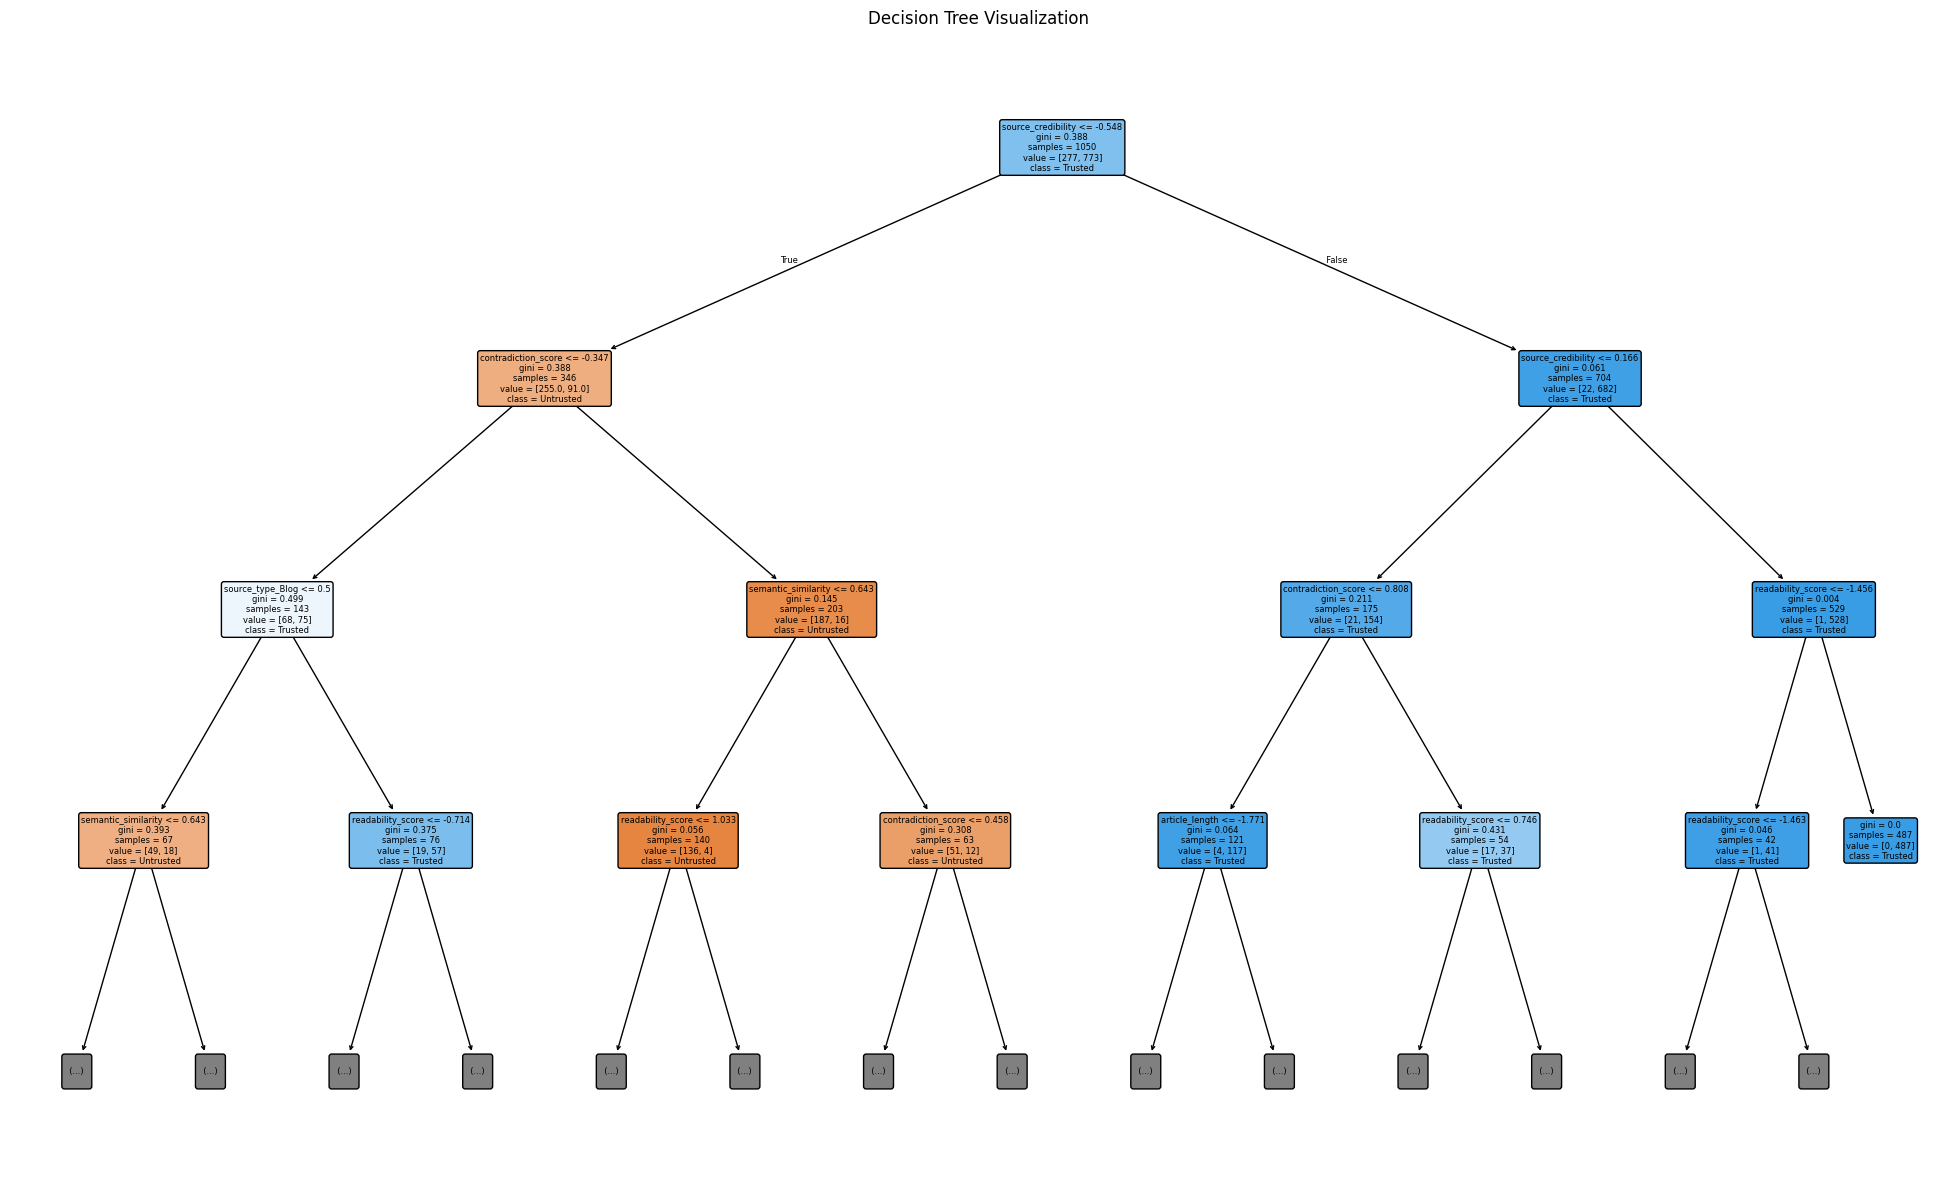

In [12]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Extract the fitted Decision Tree Classifier from the pipeline
tree_classifier = decision_tree_model.named_steps['classifier']

# Get feature names after preprocessing
# This reuses the logic from when we generated the text-based tree rules
feature_names = []
feature_names.extend(numerical_features)
onehot_features = decision_tree_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names.extend(onehot_features)

plt.figure(figsize=(25, 15))
plot_tree(tree_classifier,
          filled=True,
          feature_names=feature_names,
          class_names=['Untrusted', 'Trusted'],
          rounded=True,
          max_depth=3) # You can adjust max_depth to control the depth of the visualized tree
plt.title("Decision Tree Visualization")
plt.show()

5) K-MEANS CLUSTERING

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Re-use the text data from the DataFrame
X_kmeans_text = df['text']

# Vectorize the text data using TF-IDF (similar to Naive Bayes preprocessing)
tfidf_vectorizer_kmeans = TfidfVectorizer(max_features=1000) # Limiting features for manageability
X_kmeans_processed = tfidf_vectorizer_kmeans.fit_transform(X_kmeans_text)

# Determine the number of clusters. From earlier exploration, we know there are 10 unique topics.
# We'll try to cluster into 10 groups to see how well it aligns with the existing topics.
n_clusters = 10

# Train the KMeans model
kmeans_model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init for robust centroid initialization
kmeans_model.fit(X_kmeans_processed)

print(f"K-Means clustering model trained successfully with {n_clusters} clusters.")

K-Means clustering model trained successfully with 10 clusters.


In [14]:
import numpy as np

# Add the cluster labels to the original DataFrame for easier analysis
df['cluster_label'] = kmeans_model.labels_

print("Distribution of articles per cluster:")
print(df['cluster_label'].value_counts().sort_index())

print("\nTop topics within each cluster (showing first 3 articles per cluster):\n")

# Print a few example articles for each cluster
for i in range(n_clusters):
    print(f"--- Cluster {i} ---")
    cluster_articles = df[df['cluster_label'] == i]
    if not cluster_articles.empty:
        # Display the topic and text of the first 3 articles in the cluster
        for j, row in cluster_articles.head(3).iterrows():
            print(f"  Topic: {row['topic']}, Text: {row['text'][:100]}...")
    else:
        print("  (No articles in this cluster)")
    print("\n")

Distribution of articles per cluster:
cluster_label
0    293
1    154
2     81
3     97
4    142
5     43
6    133
7    107
8    295
9    155
Name: count, dtype: int64

Top topics within each cluster (showing first 3 articles per cluster):

--- Cluster 0 ---
  Topic: Sports, Text: This article discusses important concepts related to Sports....
  Topic: Sports, Text: This article discusses important concepts related to Sports....
  Topic: AI, Text: This article discusses important concepts related to AI....


--- Cluster 1 ---
  Topic: Healthcare, Text: Medical technology helps diagnose diseases more accurately....
  Topic: Technology, Text: Cloud computing allows data storage over the internet....
  Topic: Technology, Text: Machine learning helps computers learn from data....


--- Cluster 2 ---
  Topic: Education, Text: Teachers play an important role in student development....
  Topic: Education, Text: Teachers play an important role in student development....
  Topic: Environment, T

6) LINEAR REGRESSION

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Define features (X_lin_reg) and the target (y_lin_reg) for Linear Regression
# We will predict 'trust_score'
X_lin_reg = df.drop(['trust_score', 'is_trusted', 'text'], axis=1)
y_lin_reg = df['trust_score']

# Split data into training and testing sets for Linear Regression
X_lin_reg_train, X_lin_reg_test, y_lin_reg_train, y_lin_reg_test = train_test_split(X_lin_reg, y_lin_reg, test_size=0.3, random_state=42)

# Create a pipeline that first preprocesses the data then applies Linear Regression
linear_reg_model = Pipeline(steps=[
    ('preprocessor', preprocessor), # Reuse the preprocessor from earlier
    ('regressor', LinearRegression())
])

# Train the Linear Regression model
linear_reg_model.fit(X_lin_reg_train, y_lin_reg_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [16]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Make predictions on the test set
y_pred_lin_reg = linear_reg_model.predict(X_lin_reg_test)

# Evaluate the Linear Regression model
mse_lin_reg = mean_squared_error(y_lin_reg_test, y_pred_lin_reg)
rmse_lin_reg = np.sqrt(mse_lin_reg)
mae_lin_reg = mean_absolute_error(y_lin_reg_test, y_pred_lin_reg)
r2_lin_reg = r2_score(y_lin_reg_test, y_pred_lin_reg)

print(f"\nLinear Regression Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_lin_reg:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lin_reg:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lin_reg:.4f}")
print(f"R-squared (R2): {r2_lin_reg:.4f}")

# Display some actual vs. predicted values
results_lin_reg = pd.DataFrame({'Actual': y_lin_reg_test, 'Predicted': y_pred_lin_reg})
display(results_lin_reg.head())


Linear Regression Model Evaluation:
Mean Squared Error (MSE): 7.8730
Root Mean Squared Error (RMSE): 2.8059
Mean Absolute Error (MAE): 2.4056
R-squared (R2): 0.9794


,Actual,Predicted
1116,52.97,57.580572
1368,94.02,93.885625
422,30.46,28.216767
413,49.21,48.492451
451,39.92,44.013446


7)SVM

In [17]:
from sklearn.svm import SVC

# Reuse the preprocessed data (X_train, y_train, X_test, y_test) and preprocessor from Logistic Regression

# Create a pipeline with the preprocessor and Support Vector Classifier
svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])

# Train the SVM model
svm_model.fit(X_train, y_train)

print("Support Vector Machine model trained successfully.")

Support Vector Machine model trained successfully.


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

# Evaluate the SVM model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

print(f"\nSupport Vector Machine Model Evaluation:")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")



Support Vector Machine Model Evaluation:
Accuracy: 0.9578
Precision: 0.9722
Recall: 0.9692
F1-Score: 0.9707


8) RANDOM FOREST

In [19]:
from sklearn.ensemble import RandomForestClassifier

# Reuse the preprocessed data (X_train, y_train, X_test, y_test) and preprocessor from Logistic Regression

# Create a pipeline with the preprocessor and Random Forest Classifier
random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Train the Random Forest model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"\nRandom Forest Model Evaluation:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")



Random Forest Model Evaluation:
Accuracy: 0.9400
Precision: 0.9686
Recall: 0.9477
F1-Score: 0.9580
